# DFT & FFT Analysis

**Course:** Biomedical Signal Processing  
**Topic:** Discrete Fourier Transform and Fast Fourier Transform

---

## Objectives

1. Generate a chirp signal (A = 1, 5 → 200 Hz, fs = 1000 Hz)
2. Implement DFT (loop & vectorized) and FFT (recursive Cooley–Tukey) manually
3. Benchmark against NumPy's optimized FFT
4. Compare O(N²) vs O(N log N) complexity

## 1. Imports and Setup

In [1]:
import sys
from pathlib import Path

# Ensure the project root is on the Python path
PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time

from src.signal_generation import generate_chirp, plot_chirp
from src.dft import dft_loop, dft_vector
from src.fft import fft_recursive

# Directories
FIGURES_DIR = PROJECT_ROOT / "figures"
DATA_DIR = PROJECT_ROOT / "data"
FIGURES_DIR.mkdir(exist_ok=True)
DATA_DIR.mkdir(exist_ok=True)

print("Setup complete.")

Setup complete.


## 2. Chirp Signal Generation

Generate a linear chirp signal:
- Amplitude A = 1
- Duration = 1 s
- Sampling frequency fs = 1000 Hz
- Frequency sweep: f₀ = 5 Hz → f₁ = 200 Hz

In [2]:
# Generate chirp signal
t, x = generate_chirp(A=1.0, duration=1.0, fs=1000, f0=5.0, f1=200.0)

print(f"Signal length: {len(x)} samples")
print(f"Duration: {t[-1]:.3f} s")
print(f"Sampling frequency: {1 / (t[1] - t[0]):.0f} Hz")

Signal length: 1000 samples
Duration: 0.999 s
Sampling frequency: 1000 Hz


Figure saved to /home/Plutonium/Documents/Biosignals/biosignal_fft_homework/figures/chirp_signal.png


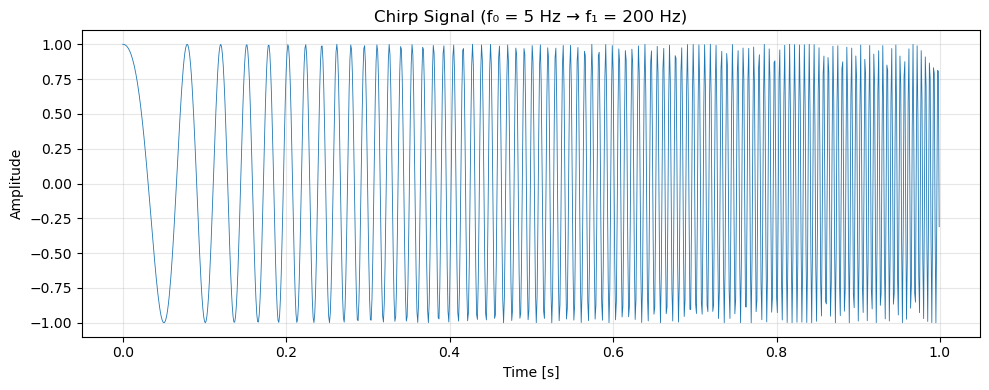

In [3]:
# Plot and save chirp signal
fig, ax = plot_chirp(t, x, save_path=FIGURES_DIR / "chirp_signal.png")
plt.show()

## 3. Algorithm Verification

Before benchmarking, verify that all implementations produce the same results as `np.fft.fft`.

We use a short test signal (N = 64, power of 2) so the loop DFT runs quickly.

In [4]:
# Use the first 64 samples for a quick correctness check
N_test = 64
x_test = x[:N_test]

X_numpy = np.fft.fft(x_test)
X_dft_loop = dft_loop(x_test)
X_dft_vec = dft_vector(x_test)
X_fft_rec = fft_recursive(x_test)

# Maximum absolute error relative to NumPy
err_dft_loop = np.max(np.abs(X_dft_loop - X_numpy))
err_dft_vec = np.max(np.abs(X_dft_vec - X_numpy))
err_fft_rec = np.max(np.abs(X_fft_rec - X_numpy))

print(f"Max error – DFT loop     : {err_dft_loop:.2e}")
print(f"Max error – DFT vector   : {err_dft_vec:.2e}")
print(f"Max error – FFT recursive: {err_fft_rec:.2e}")

assert err_dft_loop < 1e-8, "DFT loop result differs from NumPy!"
assert err_dft_vec  < 1e-8, "DFT vector result differs from NumPy!"
assert err_fft_rec  < 1e-8, "FFT recursive result differs from NumPy!"
print("\n✓ All implementations match NumPy FFT.")

Max error – DFT loop     : 1.33e-13
Max error – DFT vector   : 1.30e-13
Max error – FFT recursive: 1.24e-14

✓ All implementations match NumPy FFT.


## 4. Spectrum Comparison

Compare the magnitude spectrum produced by the DFT (loop) and the FFT (recursive) to validate that both capture the same frequency content.

Saved to /home/Plutonium/Documents/Biosignals/biosignal_fft_homework/figures/spectrum_comparison.png


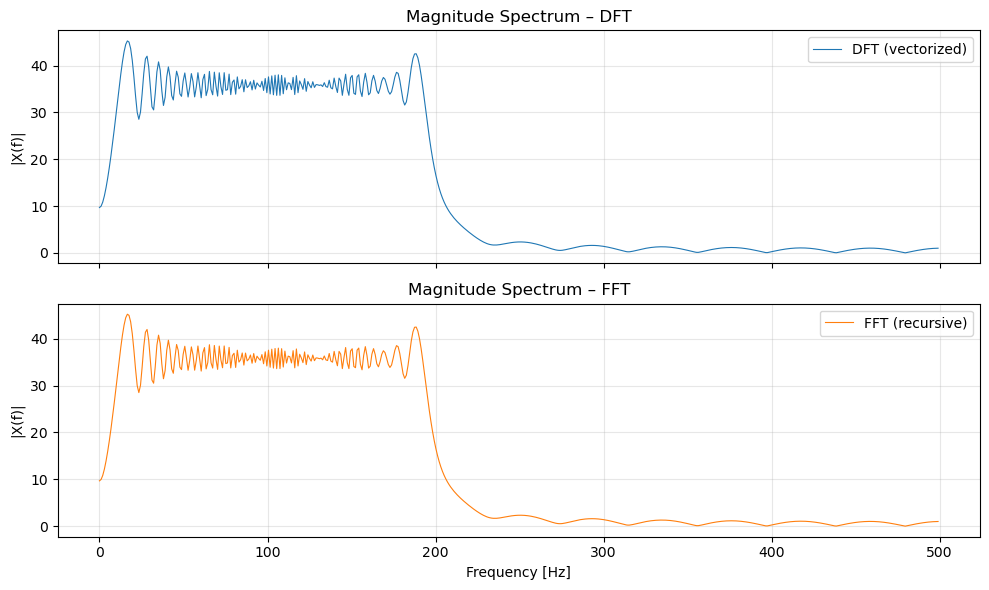

In [6]:
# Use first 1024 samples (power of 2) for spectrum comparison
# Pad signal to 1024 if needed (signal has 1000 samples)
N_spec = 1024
fs = 1000

x_spec = np.zeros(N_spec)
x_spec[:len(x)] = x
# Zero-pad the remaining samples

# Compute spectra
X_dft = dft_vector(x_spec)   # vectorized DFT (faster than loop for N=1024)
X_fft = fft_recursive(x_spec)

freqs = np.arange(N_spec) * fs / N_spec

# Only plot positive frequencies (first half)
half = N_spec // 2

fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

axes[0].plot(freqs[:half], np.abs(X_dft[:half]), linewidth=0.8, label="DFT (vectorized)")
axes[0].set_title("Magnitude Spectrum – DFT")
axes[0].set_ylabel("|X(f)|")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(freqs[:half], np.abs(X_fft[:half]), linewidth=0.8, color="tab:orange", label="FFT (recursive)")
axes[1].set_title("Magnitude Spectrum – FFT")
axes[1].set_xlabel("Frequency [Hz]")
axes[1].set_ylabel("|X(f)|")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

fig.tight_layout()
fig.savefig(FIGURES_DIR / "spectrum_comparison.png", dpi=150)
print(f"Saved to {FIGURES_DIR / 'spectrum_comparison.png'}")
plt.show()

## 5. Runtime Benchmark

Benchmark all four implementations with:
- **N = 1024** samples
- **20 repetitions** per algorithm
- Timing via `time.perf_counter()`

Results are stored as CSV files in the `data/` directory.

In [7]:
N_bench = 1024
n_runs = 20

# Pad signal to 1024 (signal has 1000 samples)
x_bench = np.zeros(N_bench)
x_bench[:len(x)] = x

def benchmark(func, x, n_runs=20):
    """Measure execution time for *func(x)* over *n_runs* repetitions."""
    times = []
    for i in range(n_runs):
        t0 = time.perf_counter()
        _ = func(x)
        t1 = time.perf_counter()
        times.append(t1 - t0)
    return times

print(f"Benchmarking with N = {N_bench}, {n_runs} runs each.")
print("This may take a few minutes (DFT loop is O(N²))...\n")

Benchmarking with N = 1024, 20 runs each.
This may take a few minutes (DFT loop is O(N²))...



In [8]:
# --- DFT loop ---
print("Running DFT (loop)...")
times_dft_loop = benchmark(dft_loop, x_bench, n_runs)
df_dft_loop = pd.DataFrame({"run_id": range(1, n_runs + 1), "execution_time_seconds": times_dft_loop})
df_dft_loop.to_csv(DATA_DIR / "runtime_dft_loop.csv", index=False)
print(f"  Mean: {np.mean(times_dft_loop):.4f} s")

Running DFT (loop)...
  Mean: 1.1396 s


In [9]:
# --- DFT vector ---
print("Running DFT (vector)...")
times_dft_vec = benchmark(dft_vector, x_bench, n_runs)
df_dft_vec = pd.DataFrame({"run_id": range(1, n_runs + 1), "execution_time_seconds": times_dft_vec})
df_dft_vec.to_csv(DATA_DIR / "runtime_dft_vector.csv", index=False)
print(f"  Mean: {np.mean(times_dft_vec):.6f} s")

Running DFT (vector)...
  Mean: 0.085556 s


In [10]:
# --- FFT recursive ---
print("Running FFT (recursive)...")
times_fft_rec = benchmark(fft_recursive, x_bench, n_runs)
df_fft_rec = pd.DataFrame({"run_id": range(1, n_runs + 1), "execution_time_seconds": times_fft_rec})
df_fft_rec.to_csv(DATA_DIR / "runtime_fft_manual.csv", index=False)
print(f"  Mean: {np.mean(times_fft_rec):.6f} s")

Running FFT (recursive)...
  Mean: 0.010211 s


In [11]:
# --- NumPy FFT ---
print("Running NumPy FFT...")
times_np_fft = benchmark(np.fft.fft, x_bench, n_runs)
df_np_fft = pd.DataFrame({"run_id": range(1, n_runs + 1), "execution_time_seconds": times_np_fft})
df_np_fft.to_csv(DATA_DIR / "runtime_fft_numpy.csv", index=False)
print(f"  Mean: {np.mean(times_np_fft):.6f} s")

print("\n✓ All benchmarks complete. CSV files saved to data/.")

Running NumPy FFT...
  Mean: 0.000078 s

✓ All benchmarks complete. CSV files saved to data/.


## 6. Statistical Analysis

Compute summary statistics (mean, std, min, max) for each algorithm.

In [12]:
# Load CSV files and compute statistics
algorithms = {
    "DFT (loop)": DATA_DIR / "runtime_dft_loop.csv",
    "DFT (vector)": DATA_DIR / "runtime_dft_vector.csv",
    "FFT (recursive)": DATA_DIR / "runtime_fft_manual.csv",
    "NumPy FFT": DATA_DIR / "runtime_fft_numpy.csv",
}

stats_rows = []
for name, path in algorithms.items():
    df = pd.read_csv(path)
    col = df["execution_time_seconds"]
    stats_rows.append({
        "Algorithm": name,
        "Mean [s]": col.mean(),
        "Std [s]": col.std(),
        "Min [s]": col.min(),
        "Max [s]": col.max(),
    })

stats_df = pd.DataFrame(stats_rows)
stats_df

,Algorithm,Mean [s],Std [s],Min [s],Max [s]
0,DFT (loop),1.139576,0.040071,1.075120,1.226904
1,DFT (vector),0.085556,0.015327,0.068839,0.131377
2,FFT (recursive),0.010211,0.001135,0.009053,0.012870
3,NumPy FFT,0.000078,0.000139,0.000022,0.000546


## 7. Runtime Comparison Plot

Bar chart comparing the average execution time of each algorithm.

Saved to /home/Plutonium/Documents/Biosignals/biosignal_fft_homework/figures/runtime_comparison.png


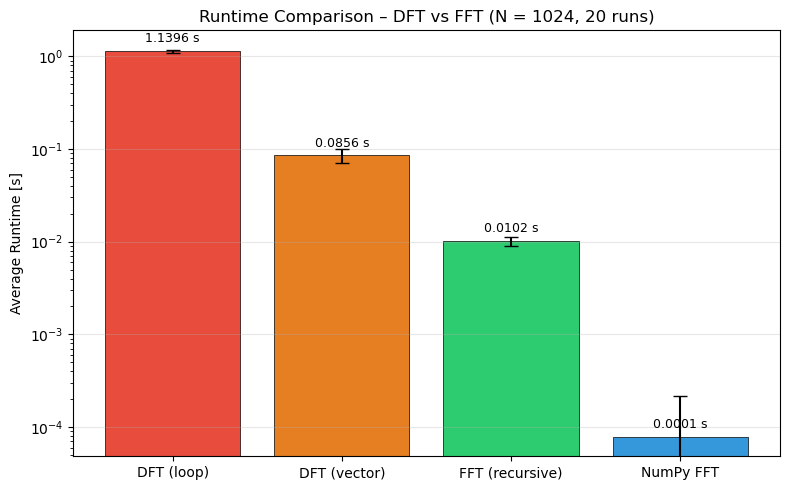

In [13]:
fig, ax = plt.subplots(figsize=(8, 5))

colors = ["#e74c3c", "#e67e22", "#2ecc71", "#3498db"]
bars = ax.bar(stats_df["Algorithm"], stats_df["Mean [s]"], color=colors,
              yerr=stats_df["Std [s]"], capsize=5, edgecolor="black", linewidth=0.5)

ax.set_ylabel("Average Runtime [s]")
ax.set_title("Runtime Comparison – DFT vs FFT (N = 1024, 20 runs)")
ax.set_yscale("log")
ax.grid(True, alpha=0.3, axis="y")

# Annotate bars with mean values
for bar, mean_val in zip(bars, stats_df["Mean [s]"]):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() * 1.15,
            f"{mean_val:.4f} s", ha="center", va="bottom", fontsize=9)

fig.tight_layout()
fig.savefig(FIGURES_DIR / "runtime_comparison.png", dpi=150)
print(f"Saved to {FIGURES_DIR / 'runtime_comparison.png'}")
plt.show()

## 8. Summary & Discussion

| Algorithm | Complexity | Notes |
|-----------|-----------|-------|
| DFT (loop) | O(N²) | Direct implementation with nested Python loops – slowest |
| DFT (vector) | O(N²) | Same complexity but leverages NumPy vectorization for speedup |
| FFT (recursive) | O(N log N) | Cooley–Tukey divide-and-conquer – much faster |
| NumPy FFT | O(N log N) | Highly optimized C implementation – fastest |

**Key observations:**
- The DFT loop is orders of magnitude slower than all other methods.
- Vectorization dramatically reduces DFT runtime despite identical O(N²) complexity.
- The recursive FFT matches NumPy's result within machine precision.
- NumPy's FFT is the fastest due to compiled C code and optimizations.
- The benchmark clearly demonstrates the O(N²) vs O(N log N) difference.